# Generamos Dashboard Exploratorio 

In [2]:
# Importamos librerias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuraramos estilo
plt.style.use('default')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 10

print("Librerias cargadas correctamente")

Librerias cargadas correctamente


In [3]:
# Cargamos los datos desde CSV
df_clientes = pd.read_csv('../datasets/clientes.csv')
df_productos = pd.read_csv('../datasets/productos.csv')
df_ventas = pd.read_csv('../datasets/ventas.csv')

print(f" Clientes: {len(df_clientes):,}")
print(f" Productos: {len(df_productos):,}")
print(f" Ventas: {len(df_ventas):,}")
print("\n Muestra de ventas:")
df_ventas.head()

 Clientes: 5,000
 Productos: 500
 Ventas: 100,000

 Muestra de ventas:


,id_venta,fecha_venta,id_cliente,id_producto,sucursal,monto
0,1,2026-10-02,1058,181,Ciudad de Guatemala,749.16
1,2,2026-04-27,4255,296,San José,666.39
2,3,2026-07-27,4677,250,San José,728.76
3,4,2026-11-02,1374,229,Tegucigalpa,112.82
4,5,2026-10-10,187,132,San José,63.06


## Ventas por País

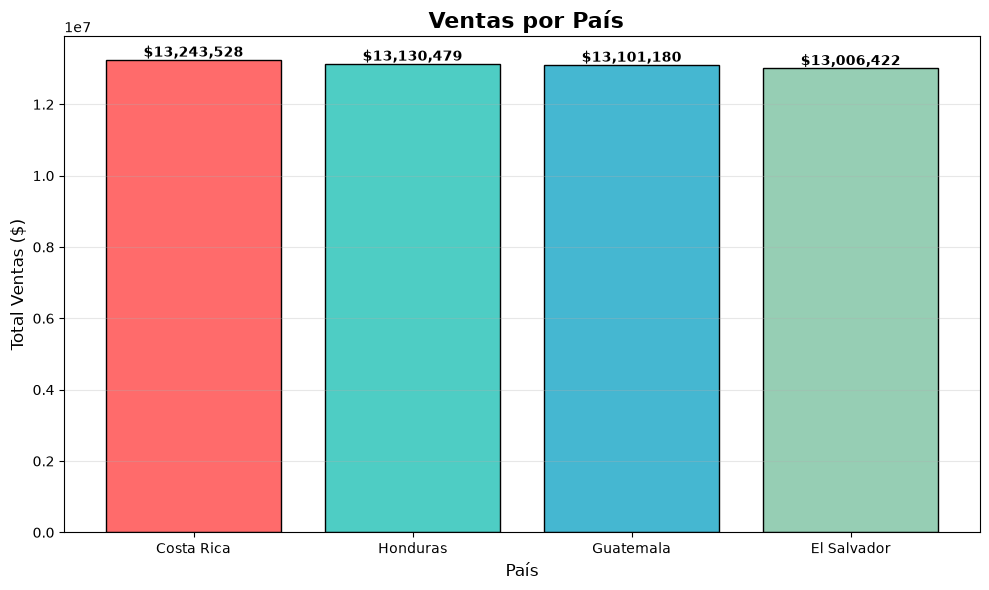

In [4]:
df_ventas_pais = df_ventas.merge(df_clientes, on='id_cliente')
ventas_pais = df_ventas_pais.groupby('pais')['monto'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = plt.bar(ventas_pais.index, ventas_pais.values, color=colors, edgecolor='black', linewidth=1)

plt.title(' Ventas por País', fontsize=16, fontweight='bold')
plt.xlabel('País', fontsize=12)
plt.ylabel('Total Ventas ($)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for bar, valor in zip(bars, ventas_pais.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
             f'${valor:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../imagenes/ventas_por_pais.png', dpi=150, bbox_inches='tight')
plt.show()

## Top 10 Productos

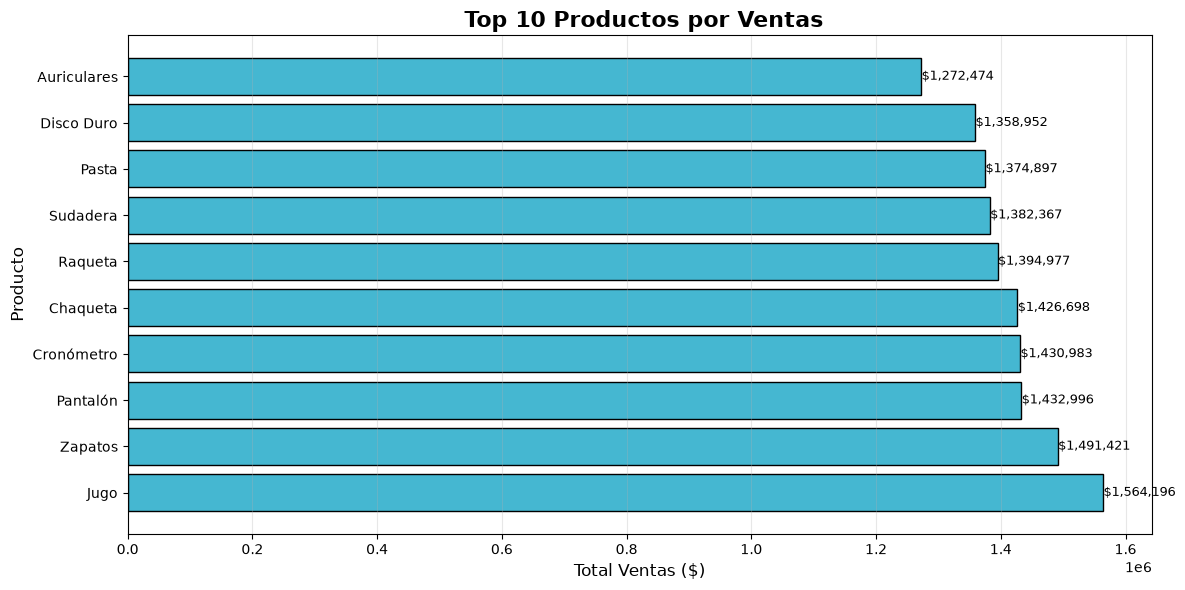

In [5]:
df_ventas_prod = df_ventas.merge(df_productos, on='id_producto')
top_productos = df_ventas_prod.groupby('producto')['monto'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_productos.index, top_productos.values, color='#45B7D1', edgecolor='black', linewidth=1)

plt.title(' Top 10 Productos por Ventas', fontsize=16, fontweight='bold')
plt.xlabel('Total Ventas ($)', fontsize=12)
plt.ylabel('Producto', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Agregar valores
for bar, valor in zip(bars, top_productos.values):
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2, 
             f'${valor:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../imagenes/top_productos.png', dpi=150, bbox_inches='tight')
plt.show()

## Ventas por Sucursal

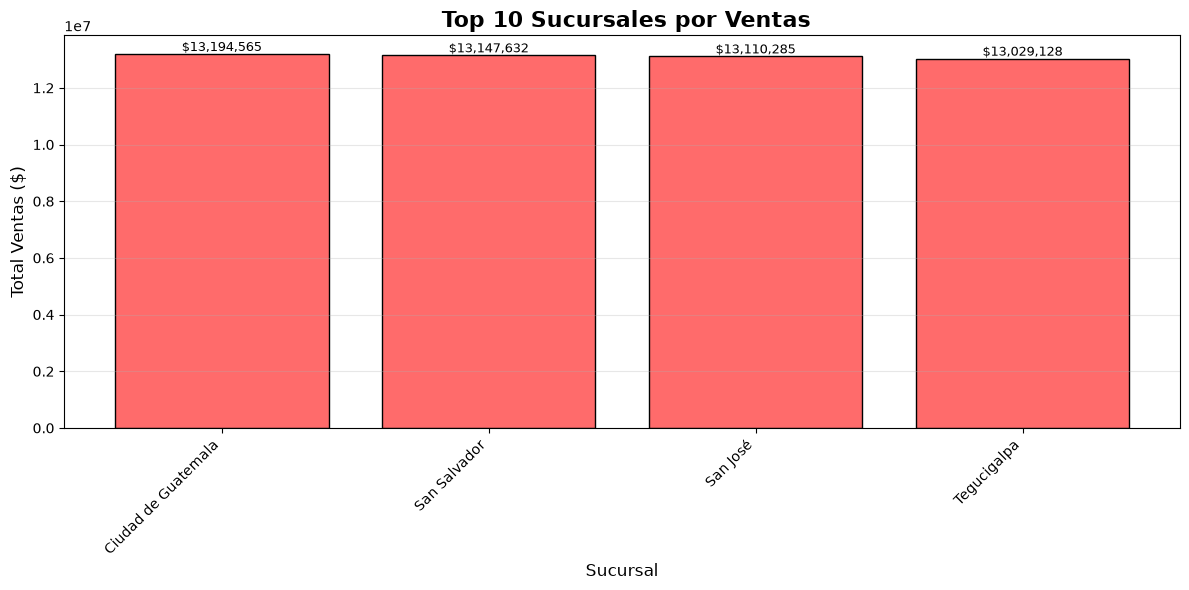

In [6]:
ventas_sucursal = df_ventas.groupby('sucursal')['monto'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(ventas_sucursal.index, ventas_sucursal.values, color='#FF6B6B', edgecolor='black', linewidth=1)

plt.title(' Top 10 Sucursales por Ventas', fontsize=16, fontweight='bold')
plt.xlabel('Sucursal', fontsize=12)
plt.ylabel('Total Ventas ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Agregar valores
for bar, valor in zip(bars, ventas_sucursal.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'${valor:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../imagenes/ventas_por_sucursal.png', dpi=150, bbox_inches='tight')
plt.show()

## Tendencia Mensual

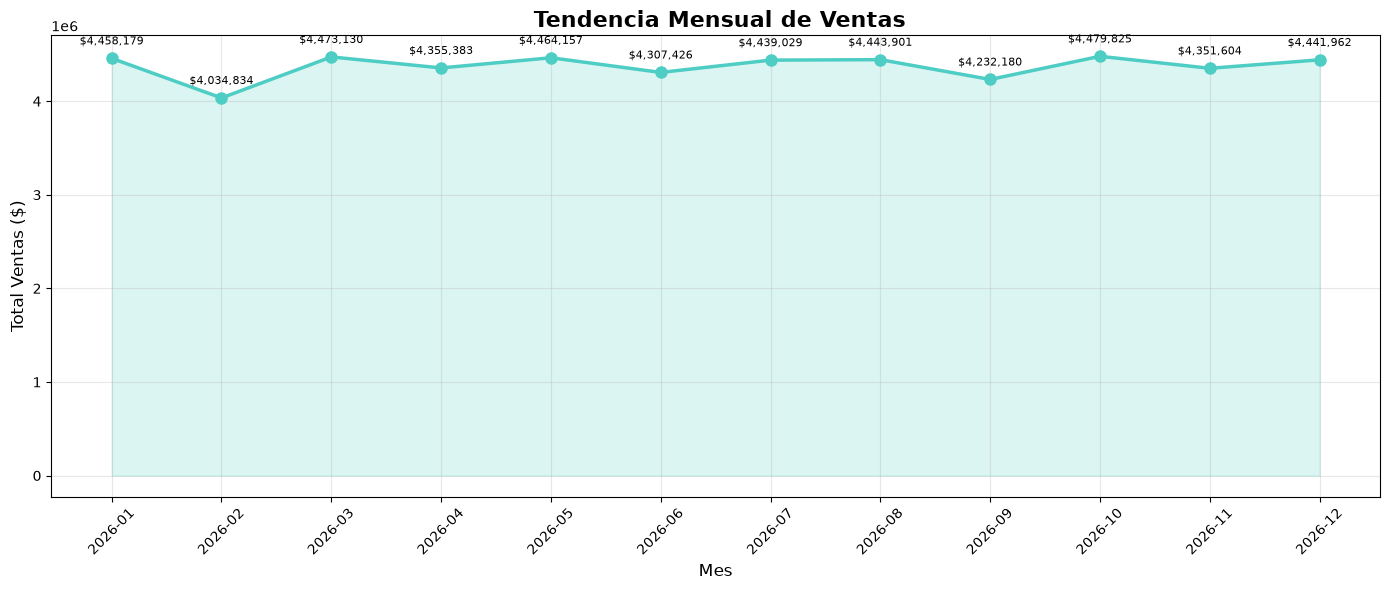

In [7]:
df_ventas['fecha_venta'] = pd.to_datetime(df_ventas['fecha_venta'])
df_ventas['mes'] = df_ventas['fecha_venta'].dt.to_period('M')
ventas_mensuales = df_ventas.groupby('mes')['monto'].sum()

# Crear etiquetas para el eje X
meses_labels = [str(m) for m in ventas_mensuales.index]

plt.figure(figsize=(14, 6))
plt.plot(range(len(ventas_mensuales)), ventas_mensuales.values, 
         marker='o', linewidth=2.5, markersize=8, color='#4ECDC4')
plt.fill_between(range(len(ventas_mensuales)), ventas_mensuales.values, 
                  alpha=0.2, color='#4ECDC4')

plt.title(' Tendencia Mensual de Ventas', fontsize=16, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Total Ventas ($)', fontsize=12)
plt.xticks(range(len(ventas_mensuales)), meses_labels, rotation=45)
plt.grid(True, alpha=0.3)

# Agregar valores
for i, valor in enumerate(ventas_mensuales.values):
    plt.annotate(f'${valor:,.0f}', (i, valor), 
                 textcoords="offset points", xytext=(0, 10), 
                 ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../imagenes/tendencia_mensual.png', dpi=150, bbox_inches='tight')
plt.show()

## Dashboard ejecutivo

In [8]:
print("=" * 70)
print(" RESUMEN EJECUTIVO - RETAIL DATA GROUP")
print("=" * 70)

# 1. País con más ventas
pais_top = ventas_pais.index[0]
print(f"\n PAÍS CON MÁS VENTAS: {pais_top}")
print(f"   Total: ${ventas_pais.iloc[0]:,.2f}")

# 2. Producto más vendido
producto_top = top_productos.index[0]
print(f"\n PRODUCTO MÁS VENDIDO: {producto_top}")
print(f"   Total: ${top_productos.iloc[0]:,.2f}")

# 3. Sucursal con mejores ventas
sucursal_top = ventas_sucursal.index[0]
print(f"\n SUCURSAL CON MEJORES VENTAS: {sucursal_top}")
print(f"   Total: ${ventas_sucursal.iloc[0]:,.2f}")

# 4. Estadísticas generales
print(f"\n ESTADÍSTICAS GENERALES:")
print(f"   Total de ventas: ${df_ventas['monto'].sum():,.2f}")
print(f"   Número de transacciones: {len(df_ventas):,}")
print(f"   Ticket promedio: ${df_ventas['monto'].mean():,.2f}")
print(f"   Venta mínima: ${df_ventas['monto'].min():,.2f}")
print(f"   Venta máxima: ${df_ventas['monto'].max():,.2f}")

# 5. Distribución por país
print(f"\n DISTRIBUCIÓN DE VENTAS POR PAÍS:")
for pais, venta in ventas_pais.items():
    porcentaje = (venta / ventas_pais.sum()) * 100
    print(f"   {pais}: ${venta:,.2f} ({porcentaje:.1f}%)")

# 6. Top 3 categorías
top_categorias = df_ventas_prod.groupby('categoria')['monto'].sum().sort_values(ascending=False).head(3)
print(f"\n TOP 3 CATEGORÍAS:")
for cat, venta in top_categorias.items():
    print(f"   {cat}: ${venta:,.2f}")

 RESUMEN EJECUTIVO - RETAIL DATA GROUP

 PAÍS CON MÁS VENTAS: Costa Rica
   Total: $13,243,528.15

 PRODUCTO MÁS VENDIDO: Jugo
   Total: $1,564,195.77

 SUCURSAL CON MEJORES VENTAS: Ciudad de Guatemala
   Total: $13,194,564.66

 ESTADÍSTICAS GENERALES:
   Total de ventas: $52,481,609.13
   Número de transacciones: 100,000
   Ticket promedio: $524.82
   Venta mínima: $50.01
   Venta máxima: $999.97

 DISTRIBUCIÓN DE VENTAS POR PAÍS:
   Costa Rica: $13,243,528.15 (25.2%)
   Honduras: $13,130,479.40 (25.0%)
   Guatemala: $13,101,179.62 (25.0%)
   El Salvador: $13,006,421.96 (24.8%)

 TOP 3 CATEGORÍAS:
   Tecnología: $11,653,450.05
   Ropa: $11,235,041.40
   Hogar: $10,072,439.14
